In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    SimpleRNN,
    LSTM,
    GRU,
    Bidirectional,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [2]:
train_df = pd.read_csv("../data/raw/train.csv")
test_df = pd.read_csv("../data/raw/test.csv")

# Remove duplicates from training data
train_df = train_df.drop_duplicates(
    subset="text"
).reset_index(drop=True)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (15969, 2)
Test shape: (2000, 2)


In [3]:
X = train_df["text"]
y = train_df["label"]

X_test = test_df["text"]
y_test = test_df["label"]

In [4]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=42,
    stratify=y
)

In [5]:
print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))
print("Test samples:", len(X_test))

Training samples: 13573
Validation samples: 2396
Test samples: 2000


In [6]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_VOCAB_SIZE = 10000
MAX_LENGTH = 50

tokenizer = Tokenizer(
    num_words=MAX_VOCAB_SIZE,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train)

Important: notice that we use:

tokenizer.fit_on_texts(X_train)

and not the validation or test data.

This prevents information leakage.

In [7]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [8]:
print("Original text:")
print(X_train.iloc[0])

print("\nSequence:")
print(X_train_seq[0])

Original text:
i feel so pissed about myself

Sequence:
[2, 3, 15, 585, 28, 49]


In [9]:
X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

X_val_pad = pad_sequences(
    X_val_seq,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

In [10]:
print("X_train:", X_train_pad.shape)
print("X_val:", X_val_pad.shape)
print("X_test:", X_test_pad.shape)

X_train: (13573, 50)
X_val: (2396, 50)
X_test: (2000, 50)


In [11]:
y_train = y_train.to_numpy()
y_val = y_val.to_numpy()
y_test = y_test.to_numpy()

In [12]:
print(y_train[:10])

[3 0 0 1 4 0 1 4 1 1]


Build the RNN


In [13]:
NUM_CLASSES = 6
EMBEDDING_DIM = 128
RNN_UNITS = 128

rnn_model = Sequential([
    Embedding(
        input_dim=MAX_VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        input_length=MAX_LENGTH
    ),

    SimpleRNN(RNN_UNITS),

    Dropout(0.5),

    Dense(NUM_CLASSES, activation="softmax")
])

rnn_model.summary()

c:\Users\karth\OneDrive\Desktop\DL_NLP_PROJECT\venv\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [14]:
rnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [15]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

If validation loss doesn't improve for 3 consecutive epochs, stop training and restore the best model weights.

This helps prevent unnecessary training and overfitting.

In [18]:
history_rnn = rnn_model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=10,
    batch_size=64,
    callbacks=[early_stopping]
)

Epoch 1/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.5687 - loss: 1.1905 - val_accuracy: 0.3715 - val_loss: 1.6635
Epoch 2/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.6805 - loss: 0.9138 - val_accuracy: 0.3823 - val_loss: 1.8126
Epoch 3/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.7551 - loss: 0.7344 - val_accuracy: 0.3689 - val_loss: 1.9489
Epoch 4/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.8206 - loss: 0.5453 - val_accuracy: 0.3794 - val_loss: 2.2149


In [19]:
rnn_test_pred = rnn_model.predict(
    X_test_pad
).argmax(axis=1)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


In [20]:
rnn_accuracy = accuracy_score(y_test, rnn_test_pred)

rnn_precision = precision_score(
    y_test,
    rnn_test_pred,
    average="macro"
)

rnn_recall = recall_score(
    y_test,
    rnn_test_pred,
    average="macro"
)

rnn_f1 = f1_score(
    y_test,
    rnn_test_pred,
    average="macro"
)

print("RNN Test Accuracy :", rnn_accuracy)
print("RNN Test Precision:", rnn_precision)
print("RNN Test Recall   :", rnn_recall)
print("RNN Test Macro F1 :", rnn_f1)

RNN Test Accuracy : 0.378
RNN Test Precision: 0.22506818552089813
RNN Test Recall   : 0.22774295995577484
RNN Test Macro F1 : 0.21814129044301248


c:\Users\karth\OneDrive\Desktop\DL_NLP_PROJECT\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [21]:
import os

os.makedirs("../models/rnn_model", exist_ok=True)

rnn_model.save("../models/rnn_model/rnn_model.keras")

In [22]:
rnn_results = pd.DataFrame({
    "Model": ["Simple RNN"],
    "Accuracy": [rnn_accuracy],
    "Precision": [rnn_precision],
    "Recall": [rnn_recall],
    "Macro F1": [rnn_f1]
})

rnn_results

,Model,Accuracy,Precision,Recall,Macro F1
0,Simple RNN,0.378,0.225068,0.227743,0.218141


In [26]:
rnn_probs = rnn_model.predict(X_test_pad)

rnn_predictions = np.argmax(rnn_probs, axis=1)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


In [27]:
rnn_accuracy = accuracy_score(y_test, rnn_predictions)

rnn_precision = precision_score(
    y_test,
    rnn_predictions,
    average="macro"
)

rnn_recall = recall_score(
    y_test,
    rnn_predictions,
    average="macro"
)

rnn_f1 = f1_score(
    y_test,
    rnn_predictions,
    average="macro"
)

print("RNN Accuracy :", rnn_accuracy)
print("RNN Precision:", rnn_precision)
print("RNN Recall   :", rnn_recall)
print("RNN Macro F1 :", rnn_f1)

RNN Accuracy : 0.378
RNN Precision: 0.22506818552089813
RNN Recall   : 0.22774295995577484
RNN Macro F1 : 0.21814129044301248


c:\Users\karth\OneDrive\Desktop\DL_NLP_PROJECT\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [28]:
print(
    classification_report(
        y_test,
        rnn_predictions,
        target_names=[
            "sadness",
            "joy",
            "love",
            "anger",
            "fear",
            "surprise"
        ]
    )
)

              precision    recall  f1-score   support

     sadness       0.36      0.53      0.43       581
         joy       0.49      0.55      0.52       695
        love       0.09      0.04      0.06       159
       anger       0.22      0.10      0.14       275
        fear       0.18      0.14      0.16       224
    surprise       0.00      0.00      0.00        66

    accuracy                           0.38      2000
   macro avg       0.23      0.23      0.22      2000
weighted avg       0.33      0.38      0.35      2000



c:\Users\karth\OneDrive\Desktop\DL_NLP_PROJECT\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\karth\OneDrive\Desktop\DL_NLP_PROJECT\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\karth\OneDrive\Desktop\DL_NLP_PROJECT\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

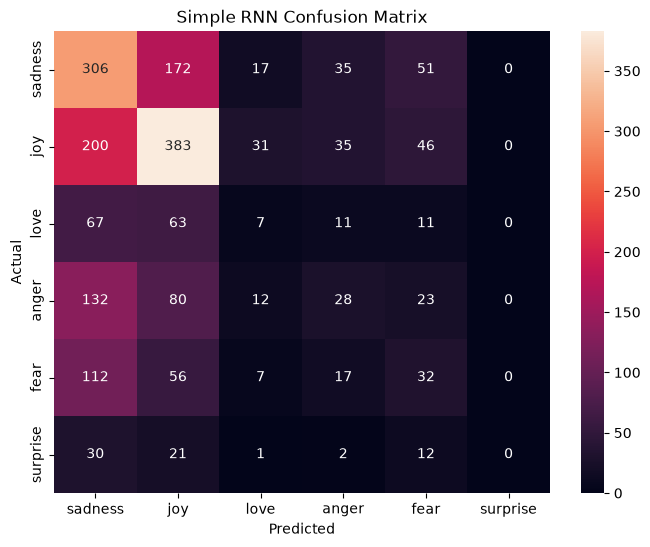

In [29]:
cm = confusion_matrix(y_test, rnn_predictions)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=[
        "sadness",
        "joy",
        "love",
        "anger",
        "fear",
        "surprise"
    ],
    yticklabels=[
        "sadness",
        "joy",
        "love",
        "anger",
        "fear",
        "surprise"
    ]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Simple RNN Confusion Matrix")
plt.show()

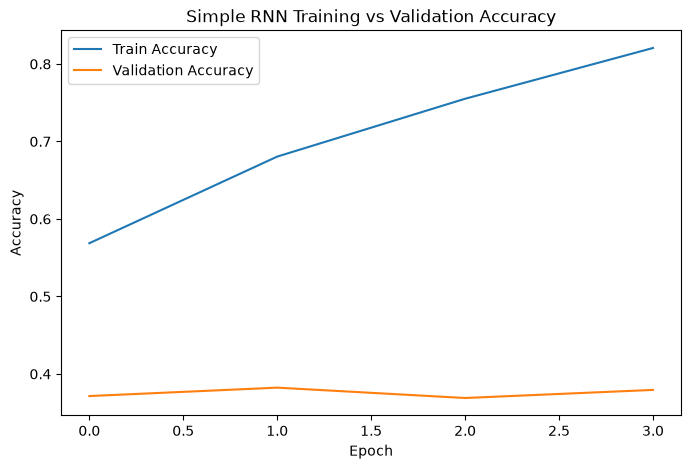

In [30]:
plt.figure(figsize=(8, 5))

plt.plot(history_rnn.history["accuracy"], label="Train Accuracy")
plt.plot(history_rnn.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Simple RNN Training vs Validation Accuracy")
plt.legend()
plt.show()


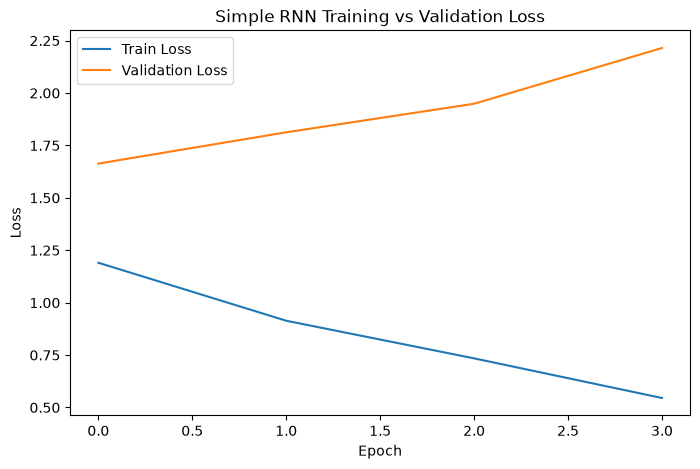

In [31]:
plt.figure(figsize=(8, 5))

plt.plot(history_rnn.history["loss"], label="Train Loss")
plt.plot(history_rnn.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Simple RNN Training vs Validation Loss")
plt.legend()
plt.show()

The Simple RNN was able to fit the training data, but its validation performance remained poor and the validation loss increased. This indicated significant overfitting.

In [32]:
import os

os.makedirs("../models/rnn_model", exist_ok=True)

rnn_model.save(
    "../models/rnn_model/rnn_model.keras"
)

In [33]:
rnn_results = pd.DataFrame({
    "Model": ["Simple RNN"],
    "Accuracy": [rnn_accuracy],
    "Precision": [rnn_precision],
    "Recall": [rnn_recall],
    "Macro F1": [rnn_f1]
})

rnn_results.to_csv(
    "../models/rnn_model/rnn_results.csv",
    index=False
)

In [34]:
history_df = pd.DataFrame(history_rnn.history)

history_df.to_csv(
    "../models/rnn_model/training_history.csv",
    index=False
)

In [23]:
rnn_results.to_csv(
    "../models/rnn_model/rnn_results.csv",
    index=False
)

In [24]:
history_df = pd.DataFrame(history_rnn.history)

history_df.to_csv(
    "../models/rnn_model/training_history.csv",
    index=False
)

## LSTM Model

In [35]:
NUM_CLASSES = 6
EMBEDDING_DIM = 128
LSTM_UNITS = 128

lstm_model = Sequential([
    Embedding(
        input_dim=MAX_VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        input_length=MAX_LENGTH
    ),

    LSTM(LSTM_UNITS),

    Dropout(0.5),

    Dense(NUM_CLASSES, activation="softmax")
])

lstm_model.summary()

c:\Users\karth\OneDrive\Desktop\DL_NLP_PROJECT\venv\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [36]:
lstm_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [37]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [38]:
history_lstm = lstm_model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=10,
    batch_size=64,
    callbacks=[early_stopping]
)

Epoch 1/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 12s 49ms/step - accuracy: 0.3270 - loss: 1.5939 - val_accuracy: 0.3351 - val_loss: 1.5800
Epoch 2/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 9s 41ms/step - accuracy: 0.3244 - loss: 1.5831 - val_accuracy: 0.3351 - val_loss: 1.5763
Epoch 3/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 8s 39ms/step - accuracy: 0.3296 - loss: 1.5794 - val_accuracy: 0.3351 - val_loss: 1.5792
Epoch 4/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 9s 44ms/step - accuracy: 0.3373 - loss: 1.5767 - val_accuracy: 0.3356 - val_loss: 1.5771
Epoch 5/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 9s 44ms/step - accuracy: 0.3361 - loss: 1.5419 - val_accuracy: 0.3301 - val_loss: 1.5015
Epoch 6/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 9s 43ms/step - accuracy: 0.3447 - loss: 1.5017 - val_accuracy: 0.3314 - val_loss: 1.5949
Epoch 7/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 9s 43ms/step - accuracy: 0.3326 - loss: 1.5779 - val_accuracy: 0.3276 - val_loss: 1.5895
Epoch 8/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - accuracy: 0.3325 - loss: 1.5803 - val_ac

In [39]:
lstm_probs = lstm_model.predict(X_test_pad)

lstm_predictions = np.argmax(
    lstm_probs,
    axis=1
)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step


In [40]:
lstm_accuracy = accuracy_score(
    y_test,
    lstm_predictions
)

lstm_precision = precision_score(
    y_test,
    lstm_predictions,
    average="macro"
)

lstm_recall = recall_score(
    y_test,
    lstm_predictions,
    average="macro"
)

lstm_f1 = f1_score(
    y_test,
    lstm_predictions,
    average="macro"
)

print("LSTM Accuracy :", lstm_accuracy)
print("LSTM Precision:", lstm_precision)
print("LSTM Recall   :", lstm_recall)
print("LSTM Macro F1 :", lstm_f1)

LSTM Accuracy : 0.349
LSTM Precision: 0.20982568798533321
LSTM Recall   : 0.2547606794082806
LSTM Macro F1 : 0.14996153031457674


c:\Users\karth\OneDrive\Desktop\DL_NLP_PROJECT\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [41]:
print(
    classification_report(
        y_test,
        lstm_predictions,
        target_names=[
            "sadness",
            "joy",
            "love",
            "anger",
            "fear",
            "surprise"
        ]
    )
)

              precision    recall  f1-score   support

     sadness       0.60      0.01      0.01       581
         joy       0.45      0.75      0.57       695
        love       0.00      0.00      0.00       159
       anger       0.00      0.00      0.00       275
        fear       0.20      0.77      0.32       224
    surprise       0.00      0.00      0.00        66

    accuracy                           0.35      2000
   macro avg       0.21      0.25      0.15      2000
weighted avg       0.36      0.35      0.24      2000



c:\Users\karth\OneDrive\Desktop\DL_NLP_PROJECT\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\karth\OneDrive\Desktop\DL_NLP_PROJECT\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\karth\OneDrive\Desktop\DL_NLP_PROJECT\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

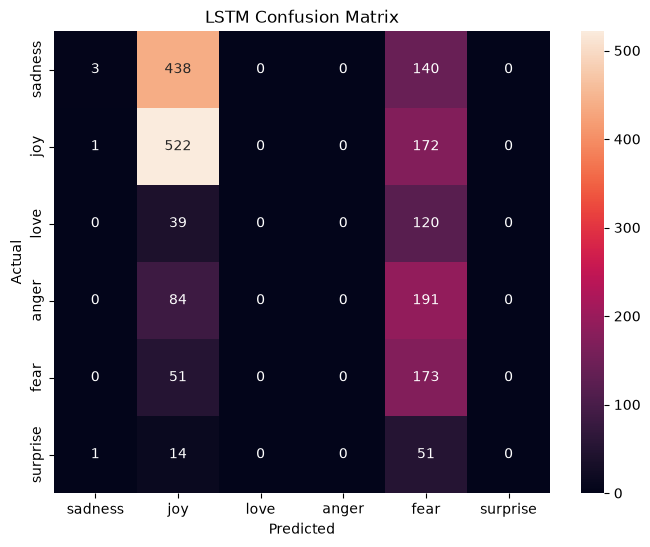

In [42]:
cm = confusion_matrix(
    y_test,
    lstm_predictions
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=[
        "sadness",
        "joy",
        "love",
        "anger",
        "fear",
        "surprise"
    ],
    yticklabels=[
        "sadness",
        "joy",
        "love",
        "anger",
        "fear",
        "surprise"
    ]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("LSTM Confusion Matrix")

plt.show()

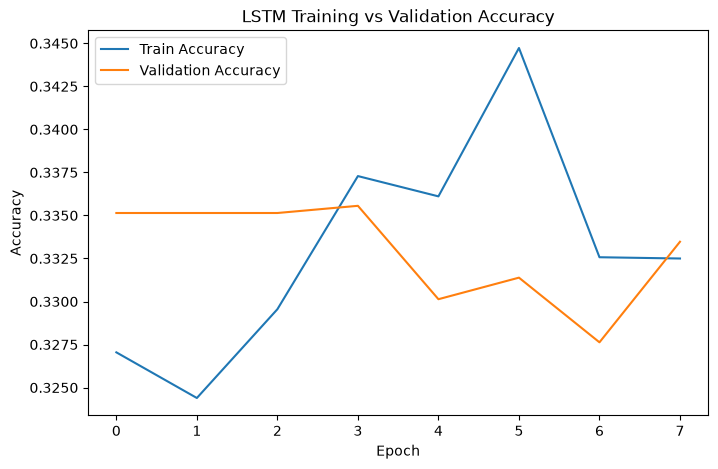

In [43]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_lstm.history["accuracy"],
    label="Train Accuracy"
)

plt.plot(
    history_lstm.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("LSTM Training vs Validation Accuracy")
plt.legend()

plt.show()

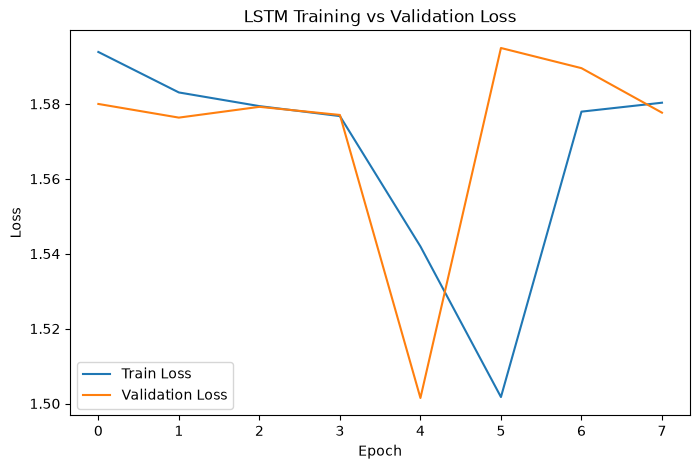

In [44]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_lstm.history["loss"],
    label="Train Loss"
)

plt.plot(
    history_lstm.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("LSTM Training vs Validation Loss")
plt.legend()

plt.show()

In [45]:
import os

os.makedirs(
    "../models/lstm_model",
    exist_ok=True
)

In [46]:
lstm_model.save(
    "../models/lstm_model/lstm_model.keras"
)

In [47]:
lstm_results = pd.DataFrame({
    "Model": ["LSTM"],
    "Accuracy": [lstm_accuracy],
    "Precision": [lstm_precision],
    "Recall": [lstm_recall],
    "Macro F1": [lstm_f1]
})

lstm_results.to_csv(
    "../models/lstm_model/lstm_results.csv",
    index=False
)

In [48]:
history_lstm_df = pd.DataFrame(
    history_lstm.history
)

history_lstm_df.to_csv(
    "../models/lstm_model/training_history.csv",
    index=False
)

## GRU Model

In [49]:
NUM_CLASSES = 6
EMBEDDING_DIM = 128
GRU_UNITS = 128

gru_model = Sequential([
    Embedding(
        input_dim=MAX_VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        input_length=MAX_LENGTH
    ),

    GRU(GRU_UNITS),

    Dropout(0.5),

    Dense(NUM_CLASSES, activation="softmax")
])

gru_model.summary()

c:\Users\karth\OneDrive\Desktop\DL_NLP_PROJECT\venv\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [50]:
gru_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [51]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [52]:
history_gru = gru_model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=10,
    batch_size=64,
    callbacks=[early_stopping]
)

Epoch 1/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 11s 43ms/step - accuracy: 0.3198 - loss: 1.5976 - val_accuracy: 0.3347 - val_loss: 1.5768
Epoch 2/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - accuracy: 0.3249 - loss: 1.5849 - val_accuracy: 0.3347 - val_loss: 1.5786
Epoch 3/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - accuracy: 0.3296 - loss: 1.5804 - val_accuracy: 0.3326 - val_loss: 1.5779
Epoch 4/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 8s 39ms/step - accuracy: 0.3276 - loss: 1.5753 - val_accuracy: 0.3210 - val_loss: 1.4836
Epoch 5/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 10s 46ms/step - accuracy: 0.6807 - loss: 0.7929 - val_accuracy: 0.8627 - val_loss: 0.4201
Epoch 6/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 11s 50ms/step - accuracy: 0.9158 - loss: 0.2420 - val_accuracy: 0.9245 - val_loss: 0.1764
Epoch 7/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 11s 50ms/step - accuracy: 0.9523 - loss: 0.1208 - val_accuracy: 0.9336 - val_loss: 0.1842
Epoch 8/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 11s 52ms/step - accuracy: 0.9626 - loss: 0.0978 - val

In [53]:
gru_probs = gru_model.predict(X_test_pad)

gru_predictions = np.argmax(
    gru_probs,
    axis=1
)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


In [54]:
gru_accuracy = accuracy_score(
    y_test,
    gru_predictions
)

gru_precision = precision_score(
    y_test,
    gru_predictions,
    average="macro"
)

gru_recall = recall_score(
    y_test,
    gru_predictions,
    average="macro"
)

gru_f1 = f1_score(
    y_test,
    gru_predictions,
    average="macro"
)

print("GRU Accuracy :", gru_accuracy)
print("GRU Precision:", gru_precision)
print("GRU Recall   :", gru_recall)
print("GRU Macro F1 :", gru_f1)


GRU Accuracy : 0.9155
GRU Precision: 0.8696518380873727
GRU Recall   : 0.8421713329362785
GRU Macro F1 : 0.8517418355470198


In [55]:
print(
    classification_report(
        y_test,
        gru_predictions,
        target_names=[
            "sadness",
            "joy",
            "love",
            "anger",
            "fear",
            "surprise"
        ]
    )
)

              precision    recall  f1-score   support

     sadness       0.94      0.96      0.95       581
         joy       0.94      0.94      0.94       695
        love       0.77      0.85      0.81       159
       anger       0.93      0.94      0.93       275
        fear       0.91      0.86      0.89       224
    surprise       0.73      0.50      0.59        66

    accuracy                           0.92      2000
   macro avg       0.87      0.84      0.85      2000
weighted avg       0.91      0.92      0.91      2000



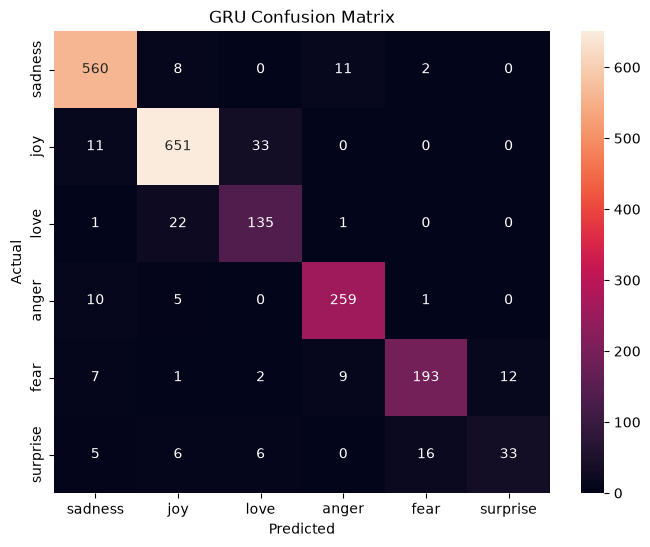

In [56]:
cm = confusion_matrix(
    y_test,
    gru_predictions
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=[
        "sadness",
        "joy",
        "love",
        "anger",
        "fear",
        "surprise"
    ],
    yticklabels=[
        "sadness",
        "joy",
        "love",
        "anger",
        "fear",
        "surprise"
    ]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("GRU Confusion Matrix")

plt.show()

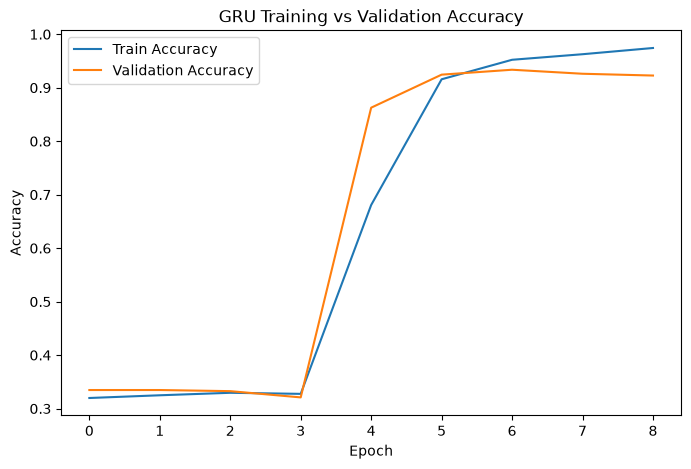

In [57]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_gru.history["accuracy"],
    label="Train Accuracy"
)

plt.plot(
    history_gru.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("GRU Training vs Validation Accuracy")
plt.legend()

plt.show()

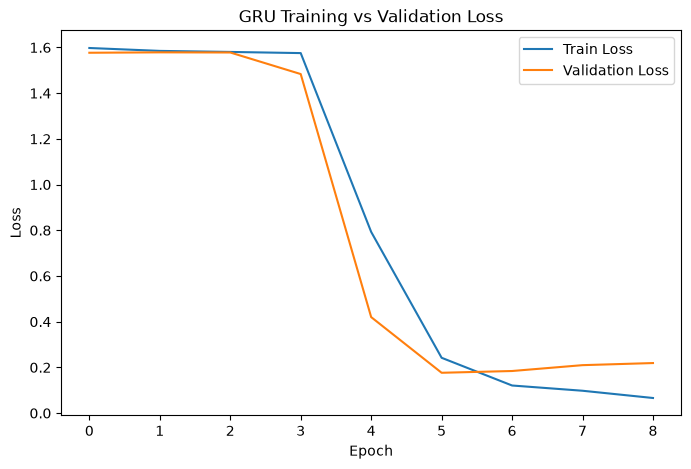

In [58]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_gru.history["loss"],
    label="Train Loss"
)

plt.plot(
    history_gru.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GRU Training vs Validation Loss")
plt.legend()

plt.show()

In [59]:
import os

os.makedirs(
    "../models/gru_model",
    exist_ok=True
)

In [60]:
gru_model.save(
    "../models/gru_model/gru_model.keras"
)

In [61]:
gru_results = pd.DataFrame({
    "Model": ["GRU"],
    "Accuracy": [gru_accuracy],
    "Precision": [gru_precision],
    "Recall": [gru_recall],
    "Macro F1": [gru_f1]
})

gru_results.to_csv(
    "../models/gru_model/gru_results.csv",
    index=False
)


In [62]:
history_gru_df = pd.DataFrame(
    history_gru.history
)

history_gru_df.to_csv(
    "../models/gru_model/training_history.csv",
    index=False
)

## Bidirectional GRU Model

A Bidirectional GRU processes the input sequence in both forward and backward
directions. This allows the model to capture contextual information from both
past and future tokens.

Architecture:

Embedding
↓
Bidirectional GRU
↓
Dropout
↓
Bidirectional GRU
↓
Dropout
↓
Dense + Softmax

In [63]:
NUM_CLASSES = 6
EMBEDDING_DIM = 128

bigru_model = Sequential([
    Embedding(
        input_dim=MAX_VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        input_length=MAX_LENGTH
    ),

    Bidirectional(
        GRU(128, return_sequences=True)
    ),

    Dropout(0.5),

    Bidirectional(
        GRU(64)
    ),

    Dropout(0.5),

    Dense(
        NUM_CLASSES,
        activation="softmax"
    )
])

bigru_model.summary()

c:\Users\karth\OneDrive\Desktop\DL_NLP_PROJECT\venv\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

The first GRU uses:

return_sequences=True

because its output is going into another GRU.

The second GRU does not use return_sequences=True because we want one final representation of the sentence before classification

In [64]:
bigru_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [65]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history_bigru = bigru_model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=10,
    batch_size=64,
    callbacks=[early_stopping]
)

Epoch 1/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 21s 72ms/step - accuracy: 0.4902 - loss: 1.2852 - val_accuracy: 0.7091 - val_loss: 0.8487
Epoch 2/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 15s 70ms/step - accuracy: 0.8658 - loss: 0.4068 - val_accuracy: 0.8831 - val_loss: 0.3248
Epoch 3/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 15s 70ms/step - accuracy: 0.9365 - loss: 0.1857 - val_accuracy: 0.9073 - val_loss: 0.2604
Epoch 4/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 16s 75ms/step - accuracy: 0.9596 - loss: 0.1167 - val_accuracy: 0.9107 - val_loss: 0.2652
Epoch 5/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 16s 74ms/step - accuracy: 0.9710 - loss: 0.0855 - val_accuracy: 0.9240 - val_loss: 0.2453
Epoch 6/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 16s 75ms/step - accuracy: 0.9824 - loss: 0.0528 - val_accuracy: 0.9199 - val_loss: 0.2980
Epoch 7/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 16s 76ms/step - accuracy: 0.9820 - loss: 0.0541 - val_accuracy: 0.9265 - val_loss: 0.2659
Epoch 8/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 17s 78ms/step - accuracy: 0.9814 - loss: 0.0530 - 

In [66]:
bigru_probs = bigru_model.predict(X_test_pad)

bigru_predictions = np.argmax(
    bigru_probs,
    axis=1
)

63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 69ms/step


In [67]:
bigru_accuracy = accuracy_score(
    y_test,
    bigru_predictions
)

bigru_precision = precision_score(
    y_test,
    bigru_predictions,
    average="macro"
)

bigru_recall = recall_score(
    y_test,
    bigru_predictions,
    average="macro"
)

bigru_f1 = f1_score(
    y_test,
    bigru_predictions,
    average="macro"
)

print("BiGRU Accuracy :", bigru_accuracy)
print("BiGRU Precision:", bigru_precision)
print("BiGRU Recall   :", bigru_recall)
print("BiGRU Macro F1 :", bigru_f1)


BiGRU Accuracy : 0.9095
BiGRU Precision: 0.8702098381620864
BiGRU Recall   : 0.8499877441348086
BiGRU Macro F1 : 0.8580499120897302


In [68]:
print(
    classification_report(
        y_test,
        bigru_predictions,
        target_names=[
            "sadness",
            "joy",
            "love",
            "anger",
            "fear",
            "surprise"
        ]
    )
)

              precision    recall  f1-score   support

     sadness       0.95      0.94      0.95       581
         joy       0.93      0.94      0.93       695
        love       0.79      0.81      0.80       159
       anger       0.91      0.90      0.91       275
        fear       0.86      0.91      0.88       224
    surprise       0.78      0.61      0.68        66

    accuracy                           0.91      2000
   macro avg       0.87      0.85      0.86      2000
weighted avg       0.91      0.91      0.91      2000



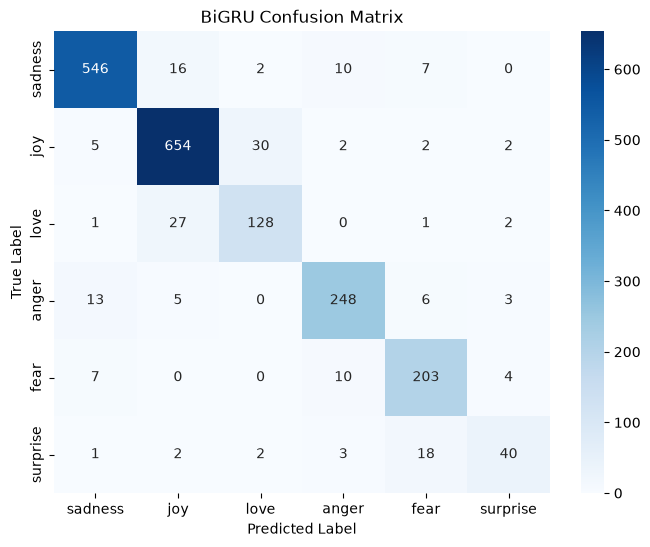

In [69]:
cm_bigru = confusion_matrix(
    y_test,
    bigru_predictions
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_bigru,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "sadness",
        "joy",
        "love",
        "anger",
        "fear",
        "surprise"
    ],
    yticklabels=[
        "sadness",
        "joy",
        "love",
        "anger",
        "fear",
        "surprise"
    ]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("BiGRU Confusion Matrix")
plt.show()

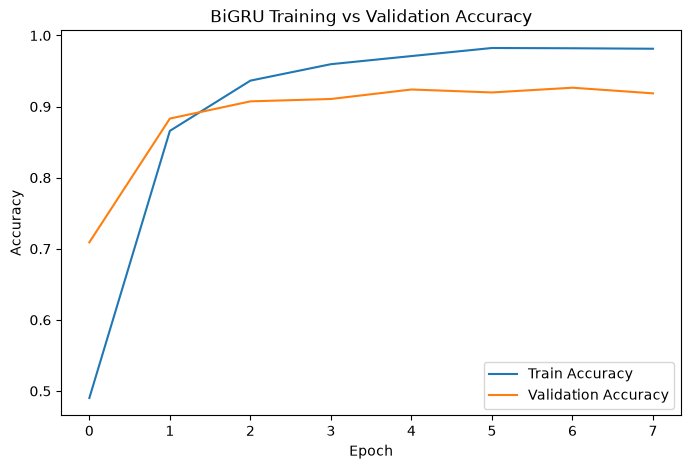

In [70]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_bigru.history["accuracy"],
    label="Train Accuracy"
)

plt.plot(
    history_bigru.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("BiGRU Training vs Validation Accuracy")
plt.legend()

plt.show()

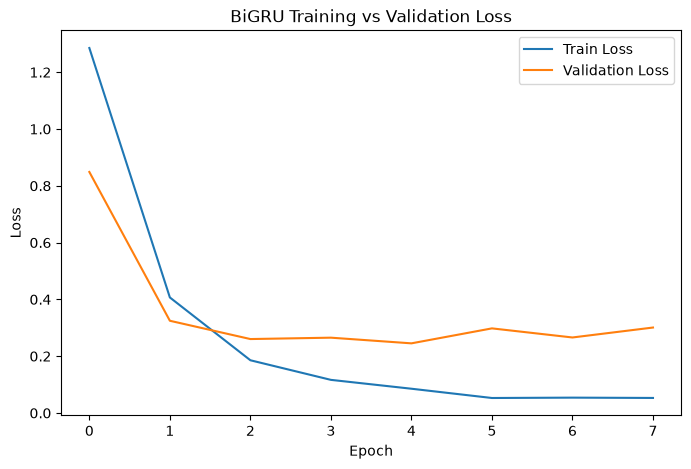

In [71]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_bigru.history["loss"],
    label="Train Loss"
)

plt.plot(
    history_bigru.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("BiGRU Training vs Validation Loss")
plt.legend()

plt.show()

In [72]:
import os

os.makedirs("../models/bigru_model", exist_ok=True)

bigru_model.save(
    "../models/bigru_model/bigru_model.keras"
)

In [73]:
bigru_results = pd.DataFrame({
    "Model": ["BiGRU"],
    "Accuracy": [bigru_accuracy],
    "Precision": [bigru_precision],
    "Recall": [bigru_recall],
    "Macro F1": [bigru_f1]
})

bigru_results.to_csv(
    "../models/bigru_model/bigru_results.csv",
    index=False
)

In [74]:
history_bigru_df = pd.DataFrame(
    history_bigru.history
)

history_bigru_df.to_csv(
    "../models/bigru_model/training_history.csv",
    index=False
)

# Create the final comparison table

In [76]:
baseline_results = pd.read_csv(
    "../models/baseline_model/baseline_results.csv"
)

In [77]:
comparison_df = pd.concat(
    [
        baseline_results,
        rnn_results,
        lstm_results,
        gru_results,
        bigru_results
    ],
    ignore_index=True
)

# Display comparison
comparison_df

,Model,Accuracy,Precision,Recall,Macro F1
0,TF-IDF + Logistic Regression,0.8295,0.851299,0.679381,0.726827
1,Simple RNN,0.3780,0.225068,0.227743,0.218141
2,LSTM,0.3490,0.209826,0.254761,0.149962
3,GRU,0.9155,0.869652,0.842171,0.851742
4,BiGRU,0.9095,0.870210,0.849988,0.858050


In [78]:
comparison_df = comparison_df.sort_values(
    by="Macro F1",
    ascending=False
).reset_index(drop=True)

comparison_df

,Model,Accuracy,Precision,Recall,Macro F1
0,BiGRU,0.9095,0.870210,0.849988,0.858050
1,GRU,0.9155,0.869652,0.842171,0.851742
2,TF-IDF + Logistic Regression,0.8295,0.851299,0.679381,0.726827
3,Simple RNN,0.3780,0.225068,0.227743,0.218141
4,LSTM,0.3490,0.209826,0.254761,0.149962


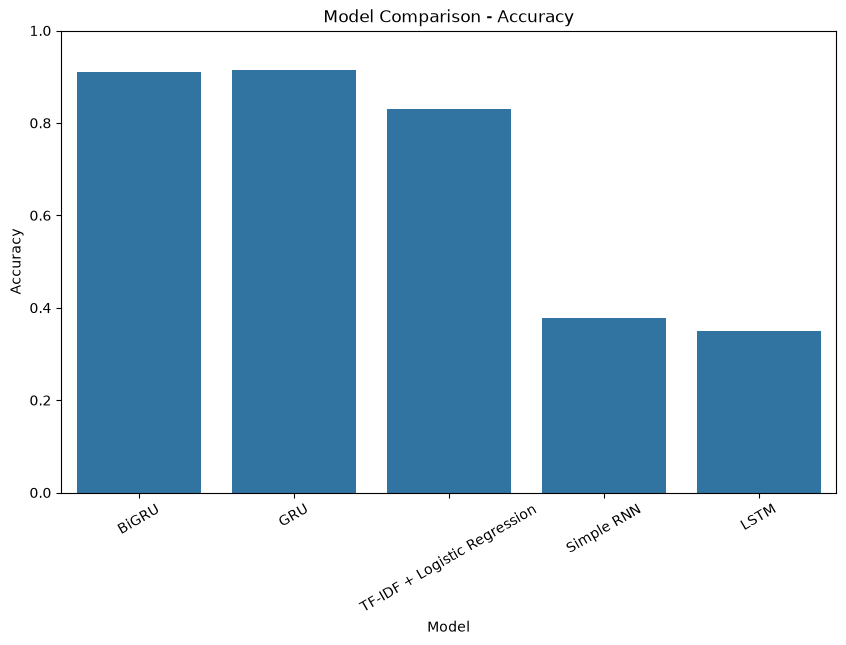

In [79]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=comparison_df,
    x="Model",
    y="Accuracy"
)

plt.xticks(rotation=30)
plt.title("Model Comparison - Accuracy")
plt.ylim(0, 1)
plt.show()

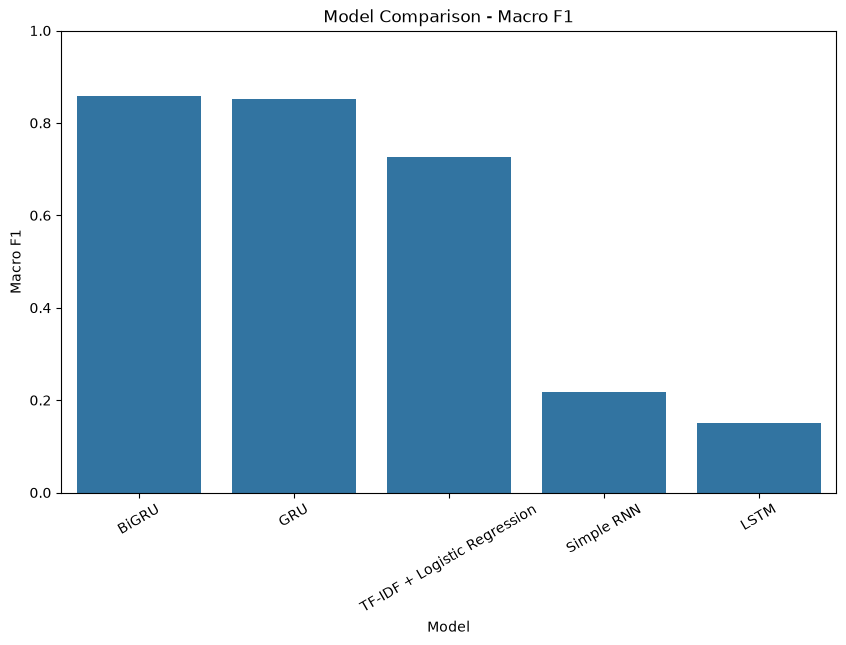

In [80]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=comparison_df,
    x="Model",
    y="Macro F1"
)

plt.xticks(rotation=30)
plt.title("Model Comparison - Macro F1")
plt.ylim(0, 1)
plt.show()

In [81]:
os.makedirs("../models/comparison", exist_ok=True)

comparison_df.to_csv(
    "../models/comparison/model_comparison.csv",
    index=False
)

## Error Analysis

We analyze incorrect predictions made by the BiGRU model to understand
which emotions are difficult to distinguish.

In [82]:
label_names = {
    0: "sadness",
    1: "joy",
    2: "love",
    3: "anger",
    4: "fear",
    5: "surprise"
}

In [91]:
error_df = pd.DataFrame({
    "text": X_test.values,
    "actual": y_test,
    "predicted": bigru_predictions
})

error_df["actual_emotion"] = error_df["actual"].map(label_names)
error_df["predicted_emotion"] = error_df["predicted"].map(label_names)

error_df.head()

,text,actual,predicted,actual_emotion,predicted_emotion
0,im feeling rather rotten so im not very ambiti...,0,0,sadness,sadness
1,im updating my blog because i feel shitty,0,0,sadness,sadness
2,i never make her separate from me because i do...,0,0,sadness,sadness
3,i left with my bouquet of red and yellow tulip...,1,1,joy,joy
4,i was feeling a little vain when i did this one,0,0,sadness,sadness


In [87]:
errors = error_df[
    error_df["actual"] != error_df["predicted"]
].copy()

print("Total test samples:", len(error_df))
print("Incorrect predictions:", len(errors))
print(
    "Error rate:",
    len(errors) / len(error_df)
)

Total test samples: 2000
Incorrect predictions: 181
Error rate: 0.0905


In [88]:
errors[
    [
        "text",
        "actual_emotion",
        "predicted_emotion"
    ]
].head(20)

,text,actual_emotion,predicted_emotion
10,i don t feel particularly agitated,fear,anger
12,i pay attention it deepens into a feeling of b...,fear,sadness
20,im not sure the feeling of loss will ever go a...,sadness,joy
54,im trying to feel out my house style now that ...,joy,sadness
55,i have tried to see what it would be like if i...,sadness,love
67,i feel a bit stressed even though all the thin...,anger,sadness
72,i am right handed however i play billiards lef...,surprise,fear
96,i love neglecting this blog but sometimes i fe...,love,joy
98,i feel my heart is tortured by what i have done,anger,fear
103,i feel agitated with myself that i did not for...,fear,anger


In [89]:
confusion_pairs = (
    errors.groupby(
        ["actual_emotion", "predicted_emotion"]
    )
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

confusion_pairs.head(15)

,actual_emotion,predicted_emotion,count
9,joy,love,30
13,love,joy,27
21,surprise,fear,18
18,sadness,joy,16
2,anger,sadness,13
4,fear,anger,10
16,sadness,anger,10
17,sadness,fear,7
5,fear,sadness,7
0,anger,fear,6


In [90]:
errors[
    (errors["actual_emotion"] == "joy") &
    (errors["predicted_emotion"] == "love")
][
    ["text", "actual_emotion", "predicted_emotion"]
].head(10)

,text,actual_emotion,predicted_emotion
199,i feel that third situation pretty much sums u...,joy,love
262,i realized what i am passionate about helping ...,joy,love
335,i believe that feeling accepted in a non judge...,joy,love
353,i could feel his breath on me and smell the sw...,joy,love
376,i suppose if one was feeling generous one coul...,joy,love
413,i am and always have been a very sincere nice ...,joy,love
489,i believe that people should choose the causes...,joy,love
496,i never feel like im not supporting,joy,love
531,i feel like i am not accepted here i and bucki...,joy,love
540,i feel like alcoholism is something that is wi...,joy,love


In [92]:
import pickle
import os

os.makedirs("../models/bigru_model", exist_ok=True)

with open("../models/bigru_model/tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

print("Tokenizer saved successfully.")

Tokenizer saved successfully.


In [93]:
text = "I am not feeling good"

cleaned_text = text.lower().strip()

sequence = tokenizer.texts_to_sequences([cleaned_text])

padded = pad_sequences(
    sequence,
    maxlen=50,
    padding="post",
    truncating="post"
)

probabilities = bigru_model.predict(padded, verbose=0)[0]

predicted_index = np.argmax(probabilities)

print("Predicted index:", predicted_index)
print("Predicted emotion:", label_names[predicted_index])
print("Probabilities:", probabilities)

Predicted index: 1
Predicted emotion: joy
Probabilities: [1.46476552e-04 9.99006331e-01 7.13098561e-04 5.58163265e-05
 6.36902842e-05 1.45616705e-05]


In [94]:
test_sentences = [
    "I am happy today",
    "I am sad today",
    "I am angry",
    "I am scared",
    "I am surprised",
    "I am not feeling good",
    "I don't feel happy",
    "I feel terrible today",
    "This is the worst day ever",
    "I am feeling great"
]

for text in test_sentences:

    cleaned_text = text.lower().strip()

    sequence = tokenizer.texts_to_sequences([cleaned_text])

    padded = pad_sequences(
        sequence,
        maxlen=50,
        padding="post",
        truncating="post"
    )

    probabilities = bigru_model.predict(
        padded,
        verbose=0
    )[0]

    predicted_index = np.argmax(probabilities)

    print(
        f"{text:35} → "
        f"{label_names[predicted_index]:10} "
        f"{probabilities[predicted_index]:.3f}"
    )

I am happy today                    → joy        0.970
I am sad today                      → sadness    0.949
I am angry                          → anger      0.963
I am scared                         → fear       0.973
I am surprised                      → surprise   0.613
I am not feeling good               → joy        0.999
I don't feel happy                  → joy        0.999
I feel terrible today               → sadness    0.999
This is the worst day ever          → joy        0.725
I am feeling great                  → sadness    0.963


In [95]:
# Inspect training examples containing specific words

words_to_check = [
    "great",
    "worst",
    "good",
    "happy",
    "terrible",
    "not"
]

for word in words_to_check:

    print("\n" + "=" * 60)
    print(f"Examples containing: '{word}'")
    print("=" * 60)

    matches = train_df[
        train_df["text"].str.lower().str.contains(
            rf"\b{word}\b",
            regex=True,
            na=False
        )
    ]

    for _, row in matches.head(10).iterrows():
        print(
            f"[{label_names[row['label']]}] "
            f"{row['text']}"
        )


Examples containing: 'great'
[joy] i was able to help chai lifeline with your support and encouragement is a great feeling and i am so glad you were able to help me
[joy] i am so festive this feels so delicious wheeeeee what a great night
[joy] i feel so tranquil right now its great
[fear] i feel intimidated by the great women in my family tree
[love] i also have to attire my regular moisturizer and an oil based primer below it yet with all those points along my skin color feels and looks tender and great all time of day something thats normally not attainable to me
[sadness] i feel like as much as it was an unfortunate situation that i wasnt with my father i was in a great place
[fear] i had a horrible tragedy something that i was terribly ashamed of or something that was causing me great pain or that was making me feel vulnerable i have more than just one or two very trusted people who i know i could call for help
[fear] i really like it a lot and think its a great fit for me and i 

In [96]:
test_sentences = [
    "I feel great",
    "I am great",
    "I am feeling great",
    "I feel really great",
    "I am feeling very great",
    "I feel happy",
    "I am feeling happy",
    "I feel good",
    "I am feeling good",
    "I am feeling terrible",
    "I feel terrible",
]

for text in test_sentences:

    cleaned_text = text.lower().strip()

    sequence = tokenizer.texts_to_sequences([cleaned_text])

    padded = pad_sequences(
        sequence,
        maxlen=50,
        padding="post",
        truncating="post"
    )

    probabilities = bigru_model.predict(
        padded,
        verbose=0
    )[0]

    predicted_index = np.argmax(probabilities)

    print(
        f"{text:30} → "
        f"{label_names[predicted_index]:10} "
        f"{probabilities[predicted_index]:.3f}"
    )

I feel great                   → sadness    0.976
I am great                     → sadness    0.736
I am feeling great             → sadness    0.963
I feel really great            → sadness    0.920
I am feeling very great        → joy        0.660
I feel happy                   → joy        0.999
I am feeling happy             → joy        0.999
I feel good                    → joy        0.999
I am feeling good              → joy        0.999
I am feeling terrible          → sadness    0.999
I feel terrible                → sadness    0.999


In [97]:
matches = train_df[
    train_df["text"]
    .str.lower()
    .str.contains("feeling great", regex=False, na=False)
]

for _, row in matches.iterrows():
    print(f"[{label_names[row['label']]}] {row['text']}")

[sadness] i feel shitty about myself or my work on the heels of feeling great for someone else s accomplishments


In [98]:
great_counts = (
    train_df[
        train_df["text"]
        .str.lower()
        .str.contains(r"\bgreat\b", regex=True, na=False)
    ]
    .groupby("label")
    .size()
    .sort_values(ascending=False)
)

for label, count in great_counts.items():
    print(f"{label_names[label]:10} → {count}")

joy        → 41
sadness    → 28
fear       → 13
anger      → 10
love       → 9
surprise   → 2


In [99]:
feel_great = train_df[
    train_df["text"]
    .str.lower()
    .str.contains("feel great", regex=False, na=False)
]

for _, row in feel_great.iterrows():
    print(f"[{label_names[row['label']]}] {row['text']}")

[anger] i never feel fucked the week after i used some i feel great acctually thinking of the wonderfull time i had the weekend before img src http israel
[sadness] i feel lethargic i just feel blah but when i m on the diet i feel great and have so much energy


In [100]:
feeling_great = train_df[
    train_df["text"]
    .str.lower()
    .str.contains("feeling great", regex=False, na=False)
]

for _, row in feeling_great.iterrows():
    print(f"[{label_names[row['label']]}] {row['text']}")

[sadness] i feel shitty about myself or my work on the heels of feeling great for someone else s accomplishments
